## Phase 1 : Dataset Exploration

### Step 1 : Import Required Libraries

In [225]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import joblib

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.preprocessing import (
    OrdinalEncoder,
    StandardScaler
)

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor
)

from xgboost import XGBRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

RANDOM_STATE = 42

### Step 2 : Load Dataset

In [226]:
dataset_path = Path(
    "../datasets/mandi_price_prediction/Agriculture_price_dataset.csv"
)

print("Dataset Exists :", dataset_path.exists())

mandi_df = pd.read_csv(dataset_path)

print("\nDataset Loaded Successfully")

print("Dataset Shape :", mandi_df.shape)

Dataset Exists : True

Dataset Loaded Successfully
Dataset Shape : (737392, 10)


### Step 3 : Dataset Overview

In [227]:
mandi_df.head()

,STATE,District Name,Market Name,Commodity,Variety,Grade,Min_Price,Max_Price,Modal_Price,Price Date
0,Maharashtra,nashik,Lasalgaon(Niphad),Wheat,Maharashtra 2189,FAQ,2172.0,2399.0,2300.0,6/6/2023
1,Maharashtra,satara,Patan,Tomato,Other,FAQ,1000.0,1500.0,1250.0,6/6/2023
2,Uttar Pradesh,mainpuri,Bewar,Potato,Local,FAQ,800.0,820.0,810.0,6/6/2023
3,Rajasthan,chittorgarh,Nimbahera,Wheat,Other,FAQ,2040.0,2668.0,2300.0,6/6/2023
4,Rajasthan,pratapgarh,Pratapgarh,Onion,Other,FAQ,476.0,1043.0,617.0,6/6/2023


In [228]:
mandi_df.tail()

,STATE,District Name,Market Name,Commodity,Variety,Grade,Min_Price,Max_Price,Modal_Price,Price Date
737387,Tamilnadu,namakkal,Kumarapalayam(Uzhavar Sandhai ),Potato,(Red Nanital),Local,3000.0,3500.0,3500.0,6/11/2025
737388,Orissa,dhenkanal,Kamakhyanagar,Potato,Potato,Non-FAQ,1900.0,2200.0,2000.0,6/11/2025
737389,Tamilnadu,dindigul,Vedasanthur(Uzhavar Sandhai ),Potato,(Red Nanital),Local,3500.0,4000.0,4000.0,6/11/2025
737390,Tamilnadu,virudhunagar,Virudhunagar(Uzhavar Sandhai ),Onion,Bellary,Local,2800.0,3000.0,3000.0,6/11/2025
737391,Haryana,yamuna nagar,Chhachrauli,Onion,Onion,FAQ,1500.0,3000.0,3000.0,6/11/2025


In [229]:
print("Rows :", mandi_df.shape[0])
print("Columns :", mandi_df.shape[1])

Rows : 737392
Columns : 10


In [230]:
mandi_df = mandi_df.copy()

print("Dataset Copy Created Successfully")

Dataset Copy Created Successfully


In [231]:
mandi_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 737392 entries, 0 to 737391
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   STATE          737392 non-null  str    
 1   District Name  737392 non-null  str    
 2   Market Name    737392 non-null  str    
 3   Commodity      737392 non-null  str    
 4   Variety        737392 non-null  str    
 5   Grade          737392 non-null  str    
 6   Min_Price      737392 non-null  float64
 7   Max_Price      737392 non-null  float64
 8   Modal_Price    737392 non-null  float64
 9   Price Date     737392 non-null  str    
dtypes: float64(3), str(7)
memory usage: 56.3 MB


### Step 4: Check Missing & Duplicate Values

In [232]:
print("Missing Values\n")

print(mandi_df.isnull().sum())

print("\nDuplicate Records :", mandi_df.duplicated().sum())

Missing Values

STATE            0
District Name    0
Market Name      0
Commodity        0
Variety          0
Grade            0
Min_Price        0
Max_Price        0
Modal_Price      0
Price Date       0
dtype: int64

Duplicate Records : 0


### Step 5 : Dataset Columns & Target Variable

In [233]:
print("Dataset Shape :", mandi_df.shape)

print("\nDataset Columns\n")

for column in mandi_df.columns:
    print(column)

print("\n")

print("Numerical Columns")

numerical_columns = mandi_df.select_dtypes(
    include=["int64","float64"]
).columns.tolist()

print(numerical_columns)

print("\nCategorical Columns")

categorical_columns = mandi_df.select_dtypes(
    include="object"
).columns.tolist()

print(categorical_columns)

target_column = "Modal_Price"

print("\nTarget Column :", target_column)

Dataset Shape : (737392, 10)

Dataset Columns

STATE
District Name
Market Name
Commodity
Variety
Grade
Min_Price
Max_Price
Modal_Price
Price Date


Numerical Columns
['Min_Price', 'Max_Price', 'Modal_Price']

Categorical Columns
['STATE', 'District Name', 'Market Name', 'Commodity', 'Variety', 'Grade', 'Price Date']

Target Column : Modal_Price


C:\Users\HP\AppData\Local\Temp\ipykernel_16932\1384766506.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = mandi_df.select_dtypes(


In [234]:
mandi_df.columns

Index(['STATE', 'District Name', 'Market Name', 'Commodity', 'Variety',
       'Grade', 'Min_Price', 'Max_Price', 'Modal_Price', 'Price Date'],
      dtype='str')

### Step 6 : Statistical Summary

In [235]:
mandi_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
STATE,737392,30,Uttar Pradesh,188094,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District Name,737392,373,bulandshahar,10716,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Market Name,737392,1598,Pratapgarh,4402,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Commodity,737392,5,Potato,327332,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Variety,737392,94,Other,226239,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Grade,737392,7,FAQ,642633,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Min_Price,737392.0,NaN,NaN,NaN,2204.849862,1920.977696,0.0,1100.0,2000.0,2700.0,420000.0
Max_Price,737392.0,NaN,NaN,NaN,2659.733824,2145.250773,0.0,1500.0,2300.0,3205.0,480000.0
Modal_Price,737392.0,NaN,NaN,NaN,2474.484638,2023.851909,0.0,1300.0,2150.0,3000.0,460000.0
Price Date,737392,737,6/12/2023,1887,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Step 7 : Exploratory Data Analysis

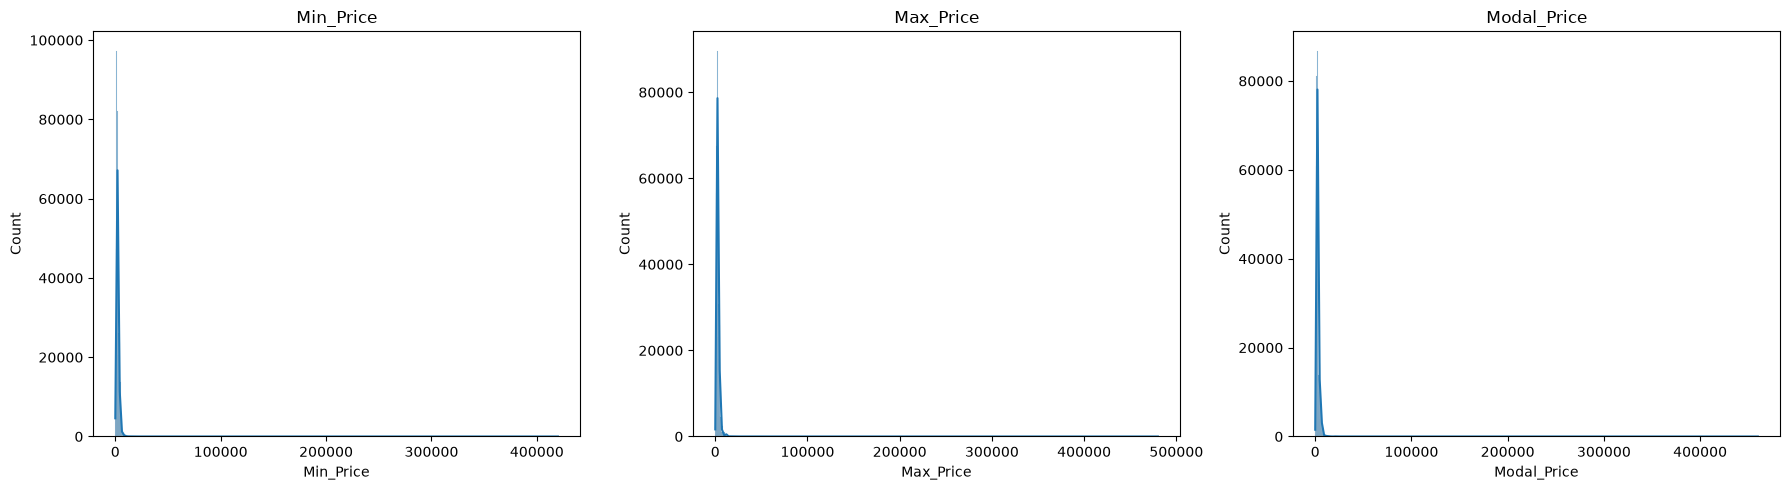

In [236]:
numerical_columns = [
    "Min_Price",
    "Max_Price",
    "Modal_Price"
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(numerical_columns):
    sns.histplot(
        mandi_df[col],
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

c:\Users\HP\Desktop\BKIS\.venv\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\HP\Desktop\BKIS\.venv\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\HP\Desktop\BKIS\.venv\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


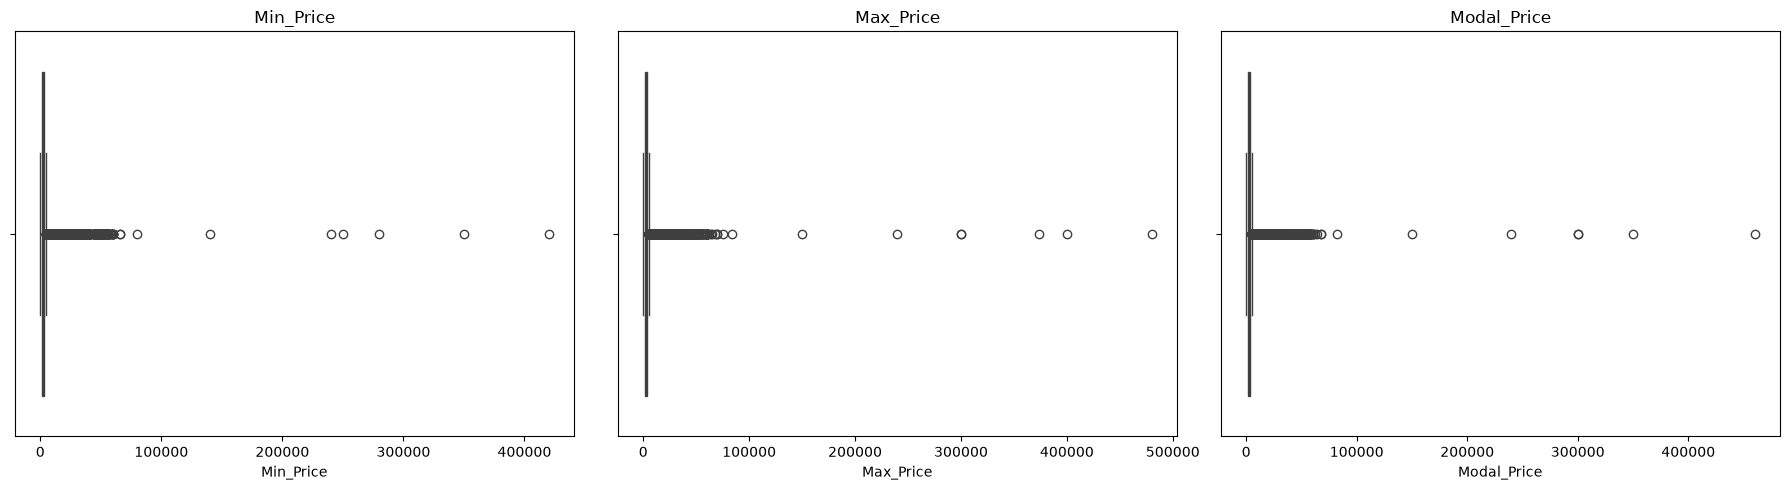

In [237]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(numerical_columns):
    sns.boxplot(
        x=mandi_df[col],
        ax=axes[i]
    )
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

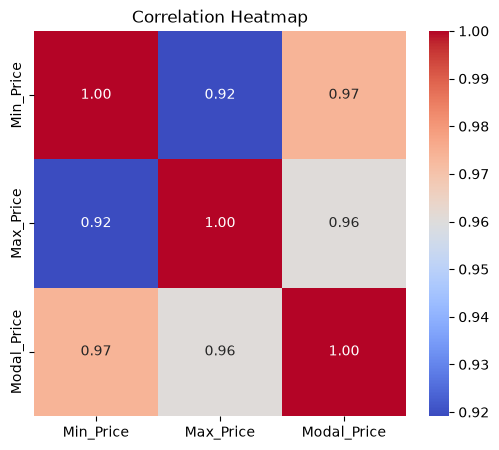

In [238]:
plt.figure(figsize=(6,5))

sns.heatmap(
    mandi_df[numerical_columns].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

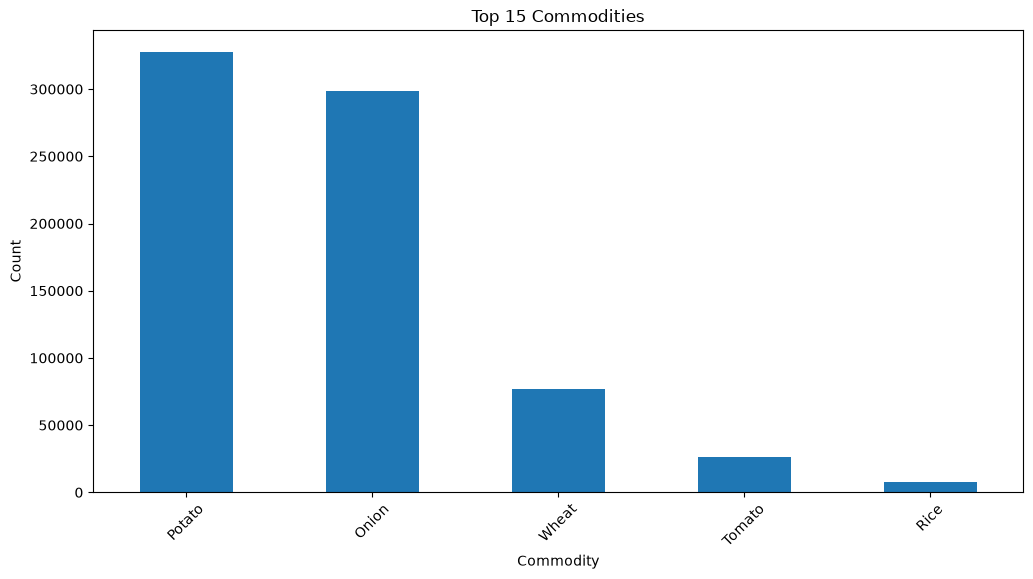

In [239]:
plt.figure(figsize=(12,6))

mandi_df["Commodity"].value_counts().head(15).plot(
    kind="bar"
)

plt.title("Top 15 Commodities")
plt.xlabel("Commodity")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

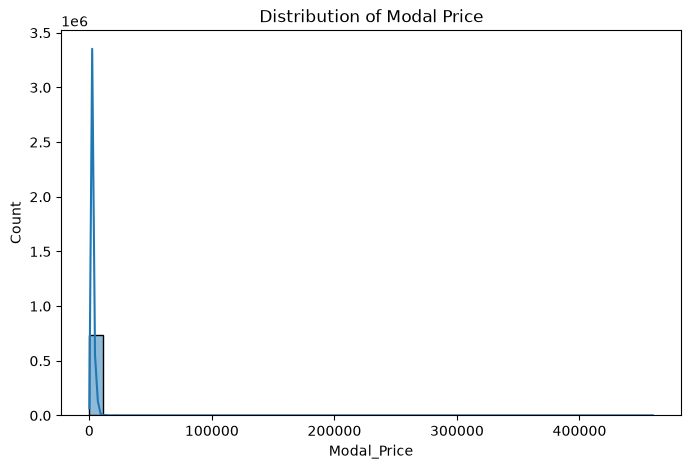

In [240]:
plt.figure(figsize=(8,5))

sns.histplot(
    mandi_df["Modal_Price"],
    bins=40,
    kde=True
)

plt.title("Distribution of Modal Price")

plt.show()

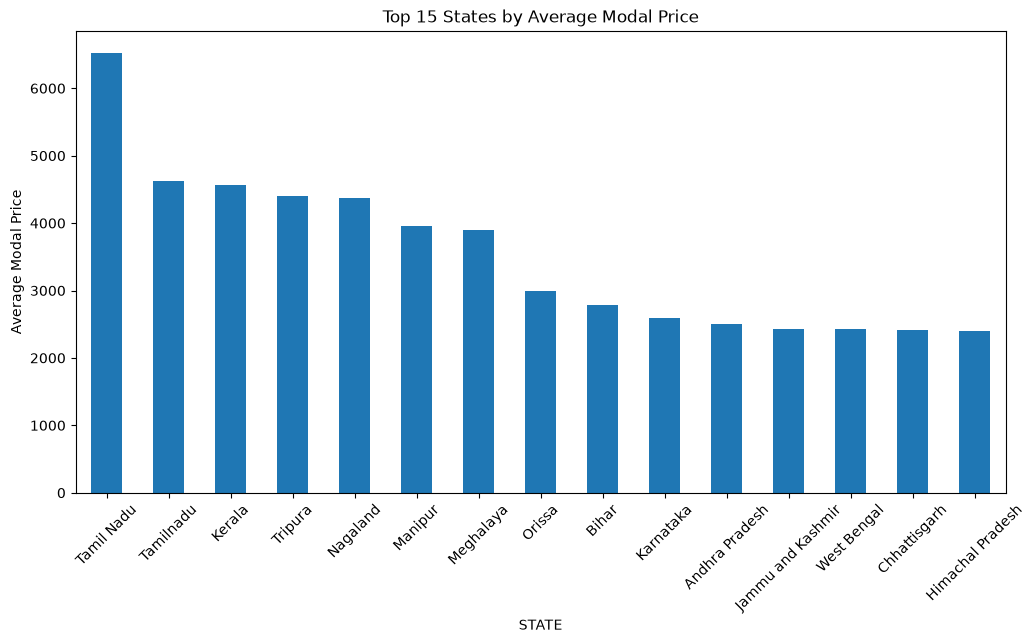

In [241]:
state_price = (
    mandi_df
    .groupby("STATE")["Modal_Price"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,6))

state_price.plot(kind="bar")

plt.title("Top 15 States by Average Modal Price")

plt.ylabel("Average Modal Price")

plt.xticks(rotation=45)

plt.show()

## Phase 2: Data Preparation

### Step 8: Data Cleaning & Feature Engineering

In [242]:
mandi_df.rename(
    columns={
        "STATE": "State",
        "District Name": "District",
        "Market Name": "Market",
        "Price Date": "Arrival_Date"
    },
    inplace=True
)

print("Columns Renamed Successfully")

print("\nUpdated Columns:\n")

print(mandi_df.columns.tolist())

Columns Renamed Successfully

Updated Columns:

['State', 'District', 'Market', 'Commodity', 'Variety', 'Grade', 'Min_Price', 'Max_Price', 'Modal_Price', 'Arrival_Date']


In [243]:
mandi_ml = mandi_df.copy()

print("Working Copy Created Successfully")

Working Copy Created Successfully


In [244]:
mandi_ml["Arrival_Date"] = pd.to_datetime(
    mandi_ml["Arrival_Date"],
    format="%m/%d/%Y",
    errors="coerce"
)

print("Missing Dates :", mandi_ml["Arrival_Date"].isna().sum())

Missing Dates : 0


In [245]:
mandi_ml["Year"] = mandi_ml["Arrival_Date"].dt.year
mandi_ml["Month"] = mandi_ml["Arrival_Date"].dt.month
mandi_ml["Day"] = mandi_ml["Arrival_Date"].dt.day
mandi_ml["DayOfWeek"] = mandi_ml["Arrival_Date"].dt.dayofweek
mandi_ml["Week"] = mandi_ml["Arrival_Date"].dt.isocalendar().week.astype(int)
mandi_ml["Quarter"] = mandi_ml["Arrival_Date"].dt.quarter

In [246]:
def get_season(month):

    if month in [12, 1, 2]:
        return "Winter"

    elif month in [3, 4, 5]:
        return "Summer"

    elif month in [6, 7, 8, 9]:
        return "Monsoon"

    else:
        return "Post-Monsoon"


mandi_ml["Season"] = mandi_ml["Month"].apply(get_season)

print("Season Feature Created Successfully")

Season Feature Created Successfully


In [247]:
new_columns = [
    "Arrival_Date",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "Week",
    "Quarter",
    "Season"
]

mandi_ml[new_columns].head()

,Arrival_Date,Year,Month,Day,DayOfWeek,Week,Quarter,Season
0,2023-06-06,2023,6,6,1,23,2,Monsoon
1,2023-06-06,2023,6,6,1,23,2,Monsoon
2,2023-06-06,2023,6,6,1,23,2,Monsoon
3,2023-06-06,2023,6,6,1,23,2,Monsoon
4,2023-06-06,2023,6,6,1,23,2,Monsoon


In [248]:
print("Dataset Shape :", mandi_ml.shape)

print("\nMissing Values :")

print(mandi_ml.isnull().sum())

print("\nData Types :")

print(mandi_ml.dtypes)

Dataset Shape : (737392, 17)

Missing Values :
State           0
District        0
Market          0
Commodity       0
Variety         0
Grade           0
Min_Price       0
Max_Price       0
Modal_Price     0
Arrival_Date    0
Year            0
Month           0
Day             0
DayOfWeek       0
Week            0
Quarter         0
Season          0
dtype: int64

Data Types :
State                      str
District                   str
Market                     str
Commodity                  str
Variety                    str
Grade                      str
Min_Price              float64
Max_Price              float64
Modal_Price            float64
Arrival_Date    datetime64[us]
Year                     int32
Month                    int32
Day                      int32
DayOfWeek                int32
Week                     int64
Quarter                  int32
Season                     str
dtype: object


### Step 9: Feature Selection

In [249]:
X = mandi_ml.drop(
    columns=[
        "Modal_Price",
        "Arrival_Date"
    ]
)

y = mandi_ml["Modal_Price"]

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (737392, 15)
Target Shape : (737392,)


In [250]:
print("Features Used:\n")

print(X.columns.tolist())

print("\nTarget Column:")

print(y.name)

Features Used:

['State', 'District', 'Market', 'Commodity', 'Variety', 'Grade', 'Min_Price', 'Max_Price', 'Year', 'Month', 'Day', 'DayOfWeek', 'Week', 'Quarter', 'Season']

Target Column:
Modal_Price


## Phase 3: Model Development

### Step 10: Train-Test Split

In [251]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (589913, 15)
Testing Set  : (147479, 15)


### Step 11 — Encode Categorical Features

In [252]:
categorical_columns = [
    "State",
    "District",
    "Market",
    "Commodity",
    "Variety",
    "Grade",
    "Season"
]

print("Categorical Columns:\n")

for col in categorical_columns:
    print(col)

Categorical Columns:

State
District
Market
Commodity
Variety
Grade
Season


In [253]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X_train[categorical_columns] = encoder.fit_transform(
    X_train[categorical_columns]
)

X_test[categorical_columns] = encoder.transform(
    X_test[categorical_columns]
)

print("Encoding Completed Successfully")

Encoding Completed Successfully


In [254]:
print("Training Data:")
display(X_train.head())

print("\nTesting Data:")
display(X_test.head())

Training Data:


,State,District,Market,Commodity,Variety,Grade,Min_Price,Max_Price,Year,Month,Day,DayOfWeek,Week,Quarter,Season
176834,11.0,132.0,223.0,0.0,79.0,0.0,2000.0,2075.0,2023,10,13,4,41,4,1.0
190544,14.0,76.0,329.0,0.0,69.0,0.0,3031.0,3031.0,2023,10,26,3,43,4,1.0
228555,16.0,323.0,747.0,4.0,52.0,0.0,2380.0,2385.0,2023,12,1,4,48,4,3.0
597852,12.0,181.0,715.0,1.0,69.0,0.0,800.0,1000.0,2025,2,11,1,7,1,3.0
448370,29.0,283.0,1186.0,1.0,44.0,0.0,2300.0,2340.0,2024,8,16,4,33,3,0.0



Testing Data:


,State,District,Market,Commodity,Variety,Grade,Min_Price,Max_Price,Year,Month,Day,DayOfWeek,Week,Quarter,Season
94016,22.0,141.0,1461.0,1.0,69.0,0.0,1300.0,1500.0,2023,8,4,4,31,3,0.0
125181,16.0,296.0,1449.0,4.0,69.0,0.0,1850.0,2700.0,2023,8,31,3,35,3,0.0
189047,16.0,323.0,1367.0,4.0,69.0,0.0,2200.0,2410.0,2023,10,25,2,43,4,1.0
598916,27.0,30.0,140.0,1.0,30.0,0.0,1050.0,1175.0,2025,2,12,2,7,1,3.0
119480,14.0,35.0,159.0,4.0,49.0,0.0,3900.0,4200.0,2023,8,25,4,34,3,0.0


### Step 12: Model Training

In [255]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor
)

from xgboost import XGBRegressor

from sklearn.metrics import r2_score

In [256]:
models = {

    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_estimators=100,
        learning_rate=0.1
    )

}

print("Models Initialized Successfully")

Models Initialized Successfully


In [257]:
results = []

print("Training Models...\n")

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    score = r2_score(y_test, predictions)

    print(f"{name:<20} R² Score : {score:.4f}")

    results.append(
        [name, score]
    )

Training Models...

Linear Regression    R² Score : 0.9215
Decision Tree        R² Score : 0.9893


c:\Users\HP\Desktop\BKIS\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\HP\Desktop\BKIS\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\HP\Desktop\BKIS\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\HP\Desktop\BKIS\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: Us

Random Forest        R² Score : 0.9669


c:\Users\HP\Desktop\BKIS\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\HP\Desktop\BKIS\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\HP\Desktop\BKIS\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\HP\Desktop\BKIS\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: Us

Extra Trees          R² Score : 0.9260
XGBoost              R² Score : 0.9653


In [258]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "R² Score"
    ]
)

results_df = results_df.sort_values(
    by="R² Score",
    ascending=False
)

results_df.reset_index(
    drop=True,
    inplace=True
)

results_df

,Model,R² Score
0,Decision Tree,0.989323
1,Random Forest,0.966919
2,XGBoost,0.965273
3,Extra Trees,0.926044
4,Linear Regression,0.921500


In [259]:
best_model_name = results_df.iloc[0]["Model"]

print("Best Model :", best_model_name)

Best Model : Decision Tree


## Phase 4: Model Evaluation

### Step 13: Evaluate Best Model

In [260]:
best_model = DecisionTreeRegressor(
    random_state=42
)

best_model.fit(
    X_train,
    y_train
)

y_pred = best_model.predict(X_test)

print("Best Model Trained Successfully")

Best Model Trained Successfully


In [261]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

r2 = r2_score(y_test, y_pred)

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

print(f"R² Score : {r2:.4f}")

print(f"MAE      : {mae:.2f}")

print(f"RMSE     : {rmse:.2f}")

R² Score : 0.9893
MAE      : 39.05
RMSE     : 205.73


In [262]:
comparison = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": y_pred

})

comparison.head(10)

,Actual,Predicted
0,1400.0,1400.0
1,2200.0,2300.0
2,2325.0,2300.0
3,1105.0,1125.0
4,4050.0,4050.0
5,2950.0,2950.0
6,1200.0,1200.0
7,4100.0,4100.0
8,3300.0,3300.0
9,5000.0,5000.0


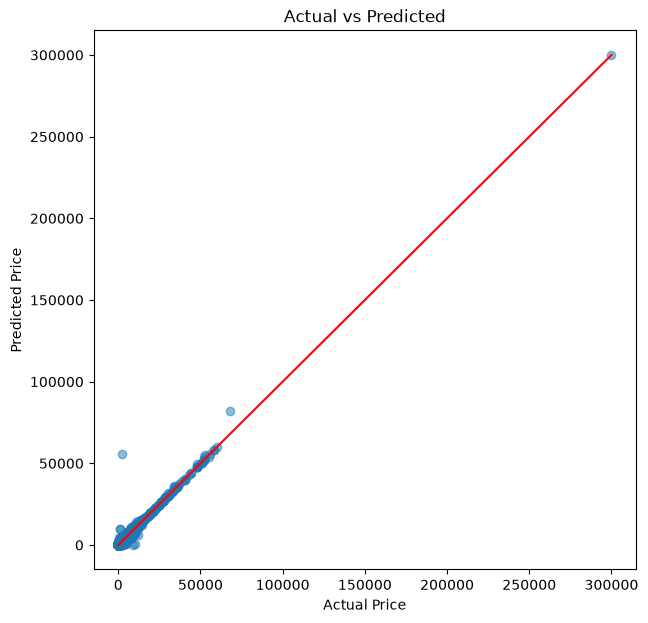

In [263]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.show()

In [264]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": best_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
7,Max_Price,0.600951
6,Min_Price,0.382653
14,Season,0.008284
12,Week,0.001572
1,District,0.001334
0,State,0.001152
2,Market,0.001131
4,Variety,0.000659
5,Grade,0.000535
3,Commodity,0.000491


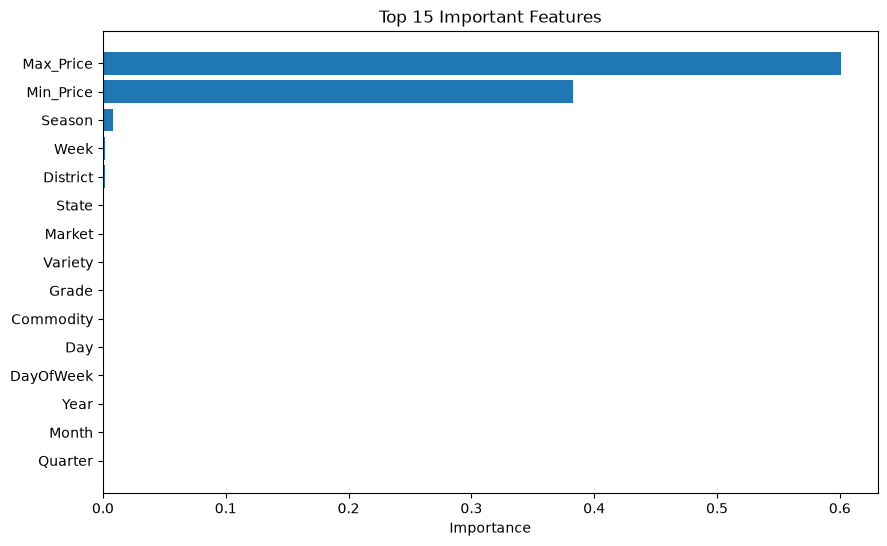

In [265]:
top_features = importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Important Features")

plt.xlabel("Importance")

plt.show()

### Step 14: Hyperparameter Tuning

In [266]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    DecisionTreeRegressor(random_state=42),
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("Cross Validation Scores:\n")

print(cv_scores)

print("\nAverage CV Score :")

print(round(cv_scores.mean(),4))

Cross Validation Scores:

[0.97238783 0.9852963  0.98246962 0.95084423 0.98411817]

Average CV Score :
0.975


In [267]:
parameters = {

    "criterion": [
        "squared_error",
        "absolute_error"
    ],

    "max_depth": [
        10,
        15,
        20,
        None
    ],

    "min_samples_split": [
        2,
        5,
        10
    ],

    "min_samples_leaf": [
        1,
        2,
        4
    ]
}

In [268]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(
        random_state=42
    ),
    param_grid=parameters,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train
)

print("Grid Search Completed Successfully")

Grid Search Completed Successfully


In [269]:
print("Best Parameters:\n")

print(grid_search.best_params_)

print("\nBest Cross Validation Score :")

print(round(grid_search.best_score_,4))

Best Parameters:

{'criterion': 'absolute_error', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best Cross Validation Score :
0.9781


In [270]:
tuned_model = grid_search.best_estimator_

tuned_predictions = tuned_model.predict(X_test)

tuned_r2 = r2_score(
    y_test,
    tuned_predictions
)

print("Tuned Model Test R² Score :")

print(round(tuned_r2,4))

Tuned Model Test R² Score :
0.9897


In [271]:
comparison = pd.DataFrame({

    "Model":[
        "Default Decision Tree",
        "Tuned Decision Tree"
    ],

    "R² Score":[
        r2_score(y_test, y_pred),
        tuned_r2
    ]

})

comparison

,Model,R² Score
0,Default Decision Tree,0.989323
1,Tuned Decision Tree,0.989679


## Phase 5: Model Deployment Preparation

### Step 15: Save Model

In [283]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    best_model,
    "../models/mandi_price_model.pkl"
)

print("Mandi Price Model Saved Successfully")

Mandi Price Model Saved Successfully


In [284]:
joblib.dump(
    encoder,
    "../models/mandi_encoder.pkl"
)
print("Mandi Encoder Saved Successfully")

Mandi Encoder Saved Successfully


In [285]:
joblib.dump(
    X.columns.tolist(),
    "../models/mandi_feature_names.pkl"
)

print("Feature Names Saved Successfully")

Feature Names Saved Successfully


### Step 16 — Test Prediction

In [286]:
loaded_model = joblib.load(
    "../models/mandi_price_model.pkl"
)

sample = X_test.iloc[[0]]

actual_price = y_test.iloc[0]

predicted_price = loaded_model.predict(sample)[0]

print("Actual Modal Price    :", round(actual_price, 2))
print("Predicted Modal Price :", round(predicted_price, 2))

c:\Users\HP\Desktop\BKIS\.venv\Lib\site-packages\joblib\numpy_pickle.py:207: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  array.shape = self.shape


Actual Modal Price    : 1400.0
Predicted Modal Price : 1400.0


In [287]:
final_r2 = r2_score(
    y_test,
    best_model.predict(X_test)
)

print("Final Model : Decision Tree Regressor")
print(f"Final Test R² Score : {final_r2:.4f}")
print("Model Ready for Deployment")

Final Model : Decision Tree Regressor
Final Test R² Score : 0.9893
Model Ready for Deployment


### Step 17: Real-Time Price Prediction

In [290]:
def predict_mandi_price(
    state,
    district,
    market,
    commodity,
    variety,
    grade,
    min_price,
    max_price,
    year,
    month,
    day,
    day_of_week,
    week,
    quarter,
    season
):

    input_data = pd.DataFrame({

        "State": [state],
        "District": [district],
        "Market": [market],
        "Commodity": [commodity],
        "Variety": [variety],
        "Grade": [grade],
        "Min_Price": [min_price],
        "Max_Price": [max_price],
        "Year": [year],
        "Month": [month],
        "Day": [day],
        "DayOfWeek": [day_of_week],
        "Week": [week],
        "Quarter": [quarter],
        "Season": [season]

    })
    input_data[categorical_columns] = encoder.transform(
        input_data[categorical_columns]
    )
    predicted_price = loaded_model.predict(
        input_data
    )[0]

    return predicted_price

In [279]:
sample_row = mandi_ml.iloc[0]

predicted_price = predict_mandi_price(

    state=sample_row["State"],
    district=sample_row["District"],
    market=sample_row["Market"],
    commodity=sample_row["Commodity"],
    variety=sample_row["Variety"],
    grade=sample_row["Grade"],

    min_price=sample_row["Min_Price"],
    max_price=sample_row["Max_Price"],

    year=sample_row["Year"],
    month=sample_row["Month"],
    day=sample_row["Day"],
    day_of_week=sample_row["DayOfWeek"],
    week=sample_row["Week"],
    quarter=sample_row["Quarter"],
    season=sample_row["Season"]
)

print(
    "Predicted Modal Price :",
    round(predicted_price, 2)
)

Predicted Modal Price : 2300.0


In [291]:
sample_raw = mandi_ml.iloc[[0]].copy()

actual_price = sample_raw["Modal_Price"].iloc[0]

sample_input = sample_raw.drop(
    columns=[
        "Modal_Price",
        "Arrival_Date"
    ]
)

sample_input[categorical_columns] = encoder.transform(
    sample_input[categorical_columns]
)

predicted_price = loaded_model.predict(
    sample_input
)[0]

print("Actual Modal Price    :", round(actual_price, 2))
print("Predicted Modal Price :", round(predicted_price, 2))

Actual Modal Price    : 2300.0
Predicted Modal Price : 2300.0
